## **PRACTICA 3**

**Estudiante**: Mariana Vásquez Ramírez

# **Resumen**

En este trabajo se analizó una señal ECG registrada y filtrada para estudiar sus características estadísticas y su comportamiento temporal. Inicialmente se cargó la señal desde un archivo .mat, se determinó su duración a partir de la frecuencia de muestreo y se construyó el vector de tiempo para su representación gráfica. Posteriormente se compararon la señal sin filtrar y filtrada, observándose que el filtrado reduce el ruido y permite identificar con mayor claridad los complejos característicos del ECG, especialmente el complejo QRS.

Luego se seleccionaron ciclos cardíacos individuales para calcular parámetros estadísticos como promedio, RMS, varianza y desviación estándar. Además, se extrajeron 15 ciclos de la señal filtrada, los cuales se graficaron y analizaron estadísticamente, evidenciando que, aunque los ciclos presentan una morfología similar, existen pequeñas variaciones en sus parámetros.

Posteriormente se realizaron comparaciones estadísticas entre ciclos, verificando primero los supuestos de normalidad y homogeneidad de varianzas mediante las pruebas de Shapiro-Wilk y Levene. Al no cumplirse completamente estos supuestos, se aplicó la prueba no paramétrica U de Mann-Whitney, la cual evidenció diferencias estadísticamente significativas entre algunos ciclos.

Ademas, se aplicó la prueba de Dickey-Fuller aumentada (ADF) para evaluar la estacionariedad de la señal, obteniéndose un p-valor de 0.0, lo que permitió rechazar la hipótesis de raíz unitaria y concluir que la señal puede considerarse aproximadamente estacionaria en el intervalo analizado, a pesar de las variaciones observadas entre ciclos individuales.

Finalmente, se desarrolló un análisis adicional utilizando señales de electroencefalografía (EEG) provenientes de dos grupos poblacionales: un grupo control y un grupo de pacientes con enfermedad de Parkinson. Para cada sujeto se calculó la energía promedio por canal, promediada a través de las diferentes épocas de la señal. Posteriormente se construyeron DataFrames para cada grupo y se evaluaron posibles diferencias estadísticas entre grupos por canal. Tras verificar los supuestos estadísticos, se aplicó la prueba no paramétrica U de Mann-Whitney, encontrándose que todos los p-valores fueron mayores a 0.05. Esto indica que no se encontraron diferencias estadísticamente significativas en la energía promedio de los canales entre los sujetos sanos y los pacientes con Parkinson.

En conjunto, los resultados muestran que el análisis estadístico y temporal de bioseñales permite caracterizar su comportamiento y evaluar posibles diferencias fisiológicas. Sin embargo, en el caso del EEG analizado, la energía promedio por canal no fue suficiente para discriminar entre sujetos sanos y pacientes con enfermedad de Parkinson, lo que sugiere la necesidad de explorar otras características de la señal, como análisis espectral o métricas en bandas de frecuencia, para identificar posibles biomarcadores más sensibles.

# **Teoría relevante**

El electrocardiograma (ECG) es una señal bioeléctrica que representa la actividad eléctrica del corazón. Su forma típica está compuesta por las ondas P, el complejo QRS y la onda T, que corresponden a los procesos de despolarización y repolarización del tejido cardíaco. En el procesamiento de bioseñales es común aplicar filtros para eliminar ruido y mejorar la calidad de la señal antes de realizar su análisis [1].

Desde el punto de vista estadístico, las señales pueden analizarse mediante parámetros como el promedio, que describe el valor medio de la señal; el valor RMS (Root Mean Square), que representa la energía efectiva de la señal; la varianza, que mide la dispersión de los datos respecto al promedio; y la desviación estándar, que indica el grado de variabilidad de la señal.

Para comparar estadísticamente diferentes segmentos de la señal se utilizan pruebas de hipótesis, como la prueba t de Student, la cual requiere que los datos cumplan ciertos supuestos, como normalidad y homogeneidad de varianzas. Cuando estos supuestos no se cumplen, se emplean pruebas no paramétricas, como la prueba U de Mann-Whitney, que no dependen de la distribución de los datos.

Finalmente, la estacionariedad es una propiedad importante en el análisis de series temporales y bioseñales. Una señal es estacionaria cuando sus propiedades estadísticas (media, varianza, autocorrelación) permanecen constantes en el tiempo. La prueba de Dickey-Fuller aumentada (ADF) se utiliza para evaluar esta propiedad determinando si la señal presenta o no una raíz unitaria [2].

In [107]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy.io as sio
from scipy.io import loadmat
from scipy.stats import shapiro, levene, ttest_ind, mannwhitneyu
import os

In [108]:
#cargar archivo .mat
data= loadmat('signals.mat')

#mostrar las variables que contienen el archivo
print(data.keys())

dict_keys(['__header__', '__version__', '__globals__', 'Fs', 'ECG_asRecording', 'ECG_filtered', 'EMG_filtered1', 'EMG_filtered2', 'EMG_asRecording1', 'EMG_asRecording2'])


In [109]:
#Extraer la señal original  (sin filtrar)
recording = data['ECG_asRecording']

#Extraer la señal filtrada
filtered = data['ECG_filtered']


In [110]:
#Crear funcion para calcular el valor RMS de una señal dada
def calcular_rms(signal):
  """Calcula el valor RMS de una señal dada."""
  rms = np.sqrt(np.mean(signal**2))

  return rms

In [111]:
#Calcular RMS de la señal original
rms_recording = calcular_rms(recording)
rms_filtered = calcular_rms(filtered)

#Mostrar resultados
print("RMS Señal original: ", rms_recording)
print("RMS Señal filtrada: ", rms_filtered)

RMS Señal original:  4392.9682937490725
RMS Señal filtrada:  286.30557115249496


In [112]:
#Aplanar las señales para facilitar el cálculo de RMS
recording = recording.flatten()
filtered = filtered.flatten()

print(recording.shape) # Debería mostrar (N,) donde N es el número de muestras

(30720,)


In [113]:
# Crear vector de tiempo para la señal ECG
fs = 1024   # frecuencia de muestreo
N = len(recording)   # número de muestras
t = np.arange(N) / fs   # vector de tiempo

print("t shape:", t.shape)
print("Número de muestras:", N)

t shape: (30720,)
Número de muestras: 30720


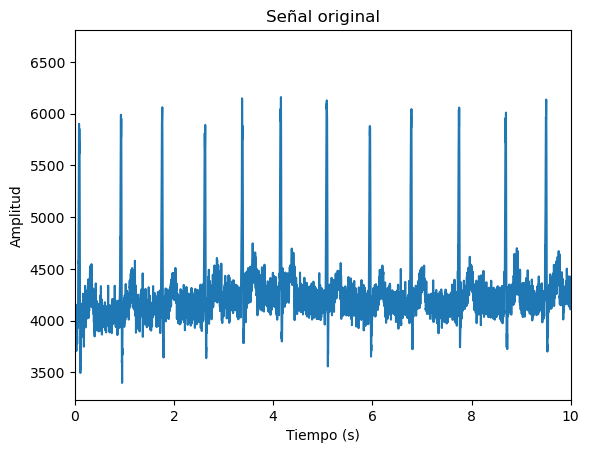

In [114]:
# Grafica de la señal original
plt.figure()
plt.plot(t, recording)
plt.title("Señal original")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.xlim(0, 10)  # Mostrar solo los primeros 10 segundos
plt.show()


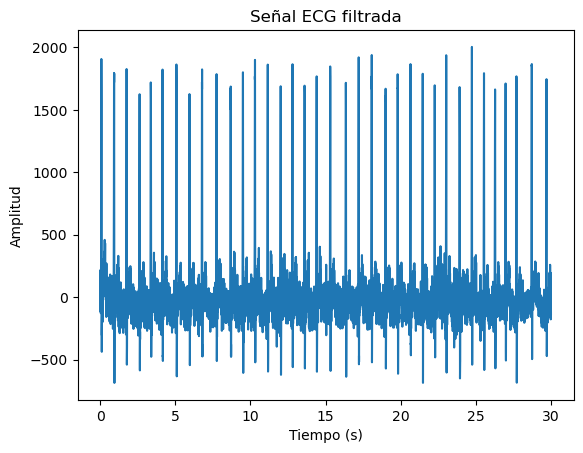

In [115]:
# Grafica de la señal filtrada
plt.figure()

plt.plot(t, filtered)

plt.title("Señal ECG filtrada")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")

plt.show()

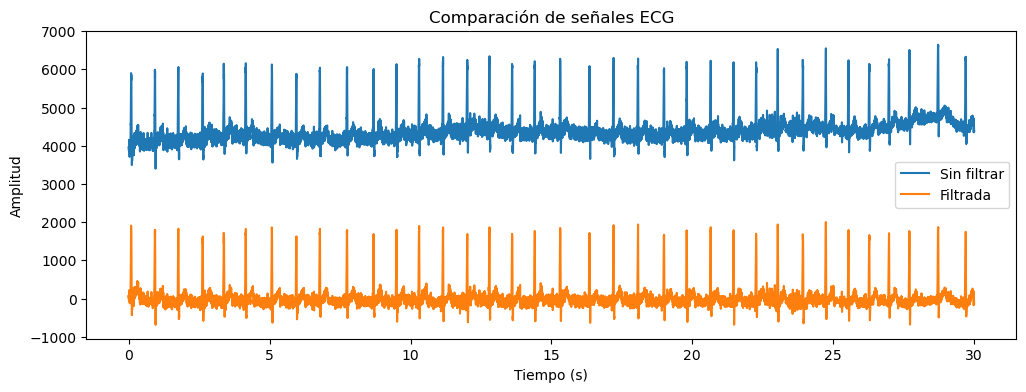

In [116]:
# Grafica de la comparación de señales
plt.figure(figsize=(12,4))

plt.plot(t, recording, label="Sin filtrar")
plt.plot(t, filtered, label="Filtrada")

plt.title("Comparación de señales ECG")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")

plt.legend()
plt.show()

Al comparar la señal ECG sin filtrar con la señal filtrada, se observa que la señal original presenta mayor ruido y variaciones en la línea base. A pesar de esto, se pueden identificar los picos correspondientes a los complejos QRS, característicos de la actividad eléctrica del corazón.

Después del filtrado, la señal muestra menor ruido y una línea base más estable, lo que permite visualizar con mayor claridad los complejos QRS y la morfología general del ECG. Esto indica que el filtro elimina componentes de ruido sin afectar significativamente la información fisiológica de la señal.

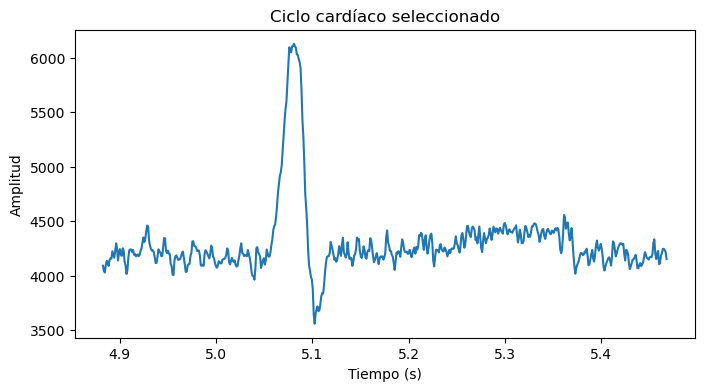

In [117]:
# Seleccionar un ciclo cardíaco específico para análisis detallado

inicio = 5000 # punto de inicio del ciclo cardíaco
fin = 5600 # punto de fin del ciclo cardíaco (ajustar según la duración del ciclo)

ciclo = recording[inicio:fin] # extraer el ciclo cardíaco de la señal original
t_ciclo = t[inicio:fin]

plt.figure(figsize=(8,4))
plt.plot(t_ciclo, ciclo)

plt.title("Ciclo cardíaco seleccionado")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")

plt.show()

In [118]:
# Calcular estadísticas del ciclo cardíaco

media = np.mean(ciclo)
varianza = np.var(ciclo)
desviacion = np.std(ciclo)
rms = calcular_rms(ciclo)

print("Promedio:", media)
print("RMS:", rms)
print("Varianza:", varianza)
print("Desviación estándar:", desviacion)

Promedio: 4296.742410888672
RMS: 4310.518937991141
Varianza: 118578.16925087877
Desviación estándar: 344.35181029127574


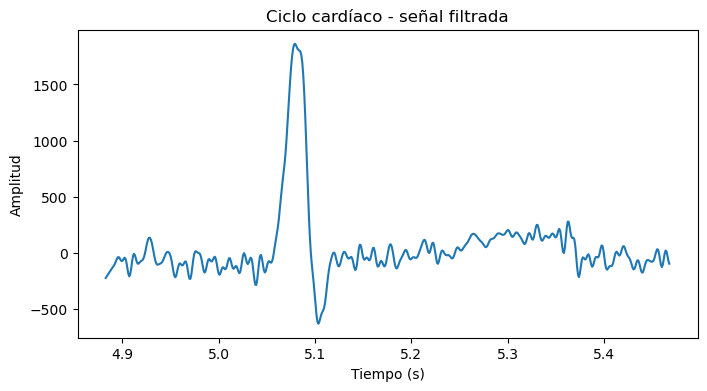

In [119]:
# Graficar el ciclo cardíaco filtrado para comparación

ciclo_filtrado = filtered[inicio:fin]
t_ciclo = t[inicio:fin]

plt.figure(figsize=(8,4))
plt.plot(t_ciclo, ciclo_filtrado)
plt.title("Ciclo cardíaco - señal filtrada")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")

plt.show()

In [120]:
# Calcular estadísticas del ciclo cardíaco filtrado

media_f = np.mean(ciclo_filtrado)
rms_f = calcular_rms(ciclo_filtrado)
varianza_f = np.var(ciclo_filtrado)
desviacion_f = np.std(ciclo_filtrado)

print("Promedio:", media_f)
print("RMS:", rms_f)
print("Varianza:", varianza_f)
print("Desviación estándar:", desviacion_f)

Promedio: 40.48947543743833
RMS: 345.0742951499519
Varianza: 117436.87155203722
Desviación estándar: 342.69063534336215


In [121]:
# Extraer múltiples ciclos cardíacos para análisis estadístico

num_ciclos = 15
tam_ciclo = 600   # aproximación del número de muestras por latido

ciclos = []

for i in range(num_ciclos):
    inicio = i * tam_ciclo
    fin = inicio + tam_ciclo
    ciclos.append(filtered[inicio:fin])
    

In [122]:
# Calcular estadísticas para cada ciclo cardíaco

promedios = []
varianzas = []

for ciclo in ciclos:
    promedios.append(np.mean(ciclo))
    varianzas.append(np.var(ciclo))

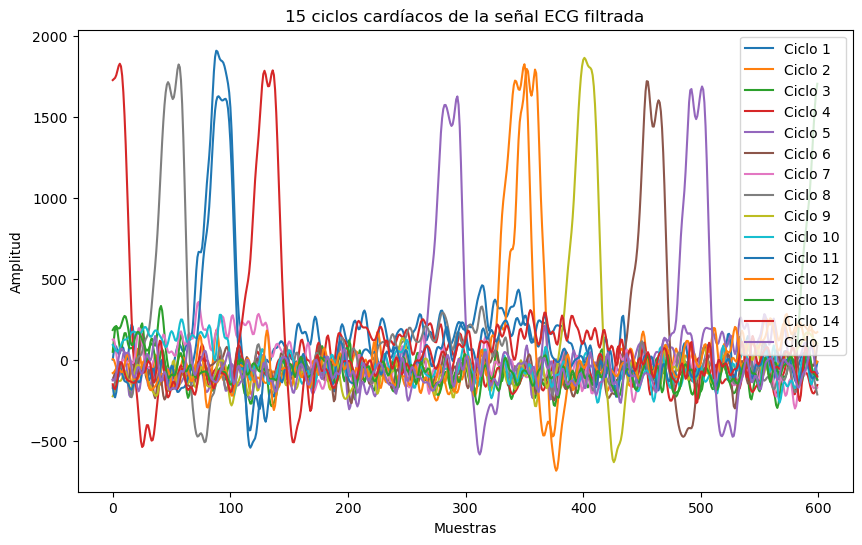

In [123]:
# Graficar los ciclos cardíacos para comparación

plt.figure(figsize=(10,6))

for i, ciclo in enumerate(ciclos):
    plt.plot(ciclo, label=f'Ciclo {i+1}')

plt.title("15 ciclos cardíacos de la señal ECG filtrada")
plt.xlabel("Muestras")
plt.ylabel("Amplitud")
plt.legend()

plt.show()

In [124]:
# Mostrar estadísticas de cada ciclo cardíaco

for i in range(num_ciclos):
    print(f"Ciclo {i+1}")
    print("Promedio:", promedios[i])
    print("Varianza:", varianzas[i])
    print()

Ciclo 1
Promedio: 148.74733367434519
Varianza: 119260.25734948255

Ciclo 2
Promedio: 23.192586168680474
Varianza: 114593.3283332458

Ciclo 3
Promedio: -50.431051307109506
Varianza: 44937.387205179555

Ciclo 4
Promedio: -0.564290611080293
Varianza: 80973.7328788919

Ciclo 5
Promedio: 12.9226754331682
Varianza: 100943.21190529646

Ciclo 6
Promedio: -12.687808550166865
Varianza: 100606.18434424893

Ciclo 7
Promedio: -16.13571327744817
Varianza: 13427.787062254136

Ciclo 8
Promedio: 36.64581230312321
Varianza: 113990.8556999689

Ciclo 9
Promedio: -11.01078473995678
Varianza: 119513.04040518375

Ciclo 10
Promedio: -36.14384627325496
Varianza: 11448.934298591254

Ciclo 11
Promedio: 36.95448138662148
Varianza: 95530.04287612683

Ciclo 12
Promedio: 27.252077159402326
Varianza: 113185.76813787963

Ciclo 13
Promedio: -68.7476657331958
Varianza: 6868.989787664017

Ciclo 14
Promedio: 60.08303105735933
Varianza: 108431.70559531041

Ciclo 15
Promedio: -17.230013456015186
Varianza: 99196.00151218892


### Análisis gráfico y estadístico de los 15 ciclos cardíacos

A partir de la gráfica de los **15 ciclos cardíacos de la señal ECG filtrada**, se observa que la mayoría de los ciclos presentan una **morfología similar**, donde se identifican picos pronunciados que corresponden al **complejo QRS**, característico de la actividad eléctrica ventricular del corazón. Aunque la forma general de los ciclos es comparable, existen **variaciones en la amplitud y en la posición de los picos**, lo cual es esperable en señales fisiológicas debido a variaciones naturales del ritmo cardíaco y a pequeñas fluctuaciones residuales de ruido.

Desde el punto de vista **estadístico**, los valores del **promedio** de los ciclos se encuentran relativamente cercanos a cero en la mayoría de los casos, lo cual indica que la señal oscila alrededor de una línea base relativamente estable después del filtrado. Sin embargo, algunos ciclos presentan promedios mayores o menores (por ejemplo, ciclo 1, ciclo 13 y ciclo 14), lo que refleja ligeras variaciones en la amplitud promedio de la señal durante esos intervalos.

En cuanto a la **varianza**, se observan diferencias significativas entre los ciclos. Algunos ciclos presentan varianzas elevadas (por ejemplo, ciclos 1, 2, 8, 9 y 14), lo cual indica mayor dispersión de los valores de amplitud debido a la presencia de picos pronunciados del complejo QRS. En contraste, otros ciclos presentan varianzas mucho menores (como los ciclos 7, 10 y 13), lo que sugiere menor variabilidad en la amplitud de la señal en esos segmentos.

Considerando tanto la **observación gráfica** como los **parámetros estadísticos**, se puede concluir que la señal ECG **no es estrictamente estacionaria**, ya que los valores de promedio y varianza cambian entre ciclos. No obstante, debido a que la morfología general del ECG se mantiene y las variaciones no son extremas, la señal puede considerarse **cuasi-estacionaria en intervalos cortos de tiempo**, lo cual es un comportamiento típico de las señales fisiológicas como el electrocardiograma.


### **Supuestos necesarios para realizar una prueba t**

In [125]:
#Seleccionar ciclos específicos para análisis detallado

ciclo1 = ciclos[0]
ciclo2 = ciclos[1]

ciclo3 = ciclos[2]
ciclo4 = ciclos[3]

#Pruebas estadísticas para comparar ciclos cardíacos

# Verificar normalidad (Prueba de Shapiro-Wilk)
print("Normalidad ciclo 1:", shapiro(ciclo1))
print("Normalidad ciclo 2:", shapiro(ciclo2))

print("Normalidad ciclo 3:", shapiro(ciclo3))
print("Normalidad ciclo 4:", shapiro(ciclo4))

# Interpretación: Si p > 0.05 → datos normales, Si p < 0.05 → datos no normales
 

Normalidad ciclo 1: ShapiroResult(statistic=0.6319543719291687, pvalue=7.017054752516104e-34)
Normalidad ciclo 2: ShapiroResult(statistic=0.5633881688117981, pvalue=4.198332888273569e-36)
Normalidad ciclo 3: ShapiroResult(statistic=0.5523458123207092, pvalue=1.958247386409195e-36)
Normalidad ciclo 4: ShapiroResult(statistic=0.5549594163894653, pvalue=2.3424002890917685e-36)


La prueba de Shapiro-Wilk se aplicó para evaluar la normalidad de los datos correspondientes a los ciclos cardíacos analizados. Los resultados obtenidos muestran valores de p extremadamente pequeños para todos los ciclos (ciclo 1: p = 7.01×10⁻³⁴, ciclo 2: p = 4.19×10⁻³⁶, ciclo 3: p = 1.95×10⁻³⁶ y ciclo 4: p = 2.34×10⁻³⁶), los cuales son mucho menores que el nivel de significancia comúnmente utilizado (α = 0.05). Por lo tanto, se rechaza la hipótesis nula de normalidad, concluyendo que los datos de los ciclos cardíacos no siguen una distribución normal. Este comportamiento es esperado en señales fisiológicas como el ECG, ya que la presencia de picos pronunciados asociados al complejo QRS genera distribuciones asimétricas y alejadas de una distribución gaussiana. En consecuencia, al no cumplirse el supuesto de normalidad requerido para aplicar una prueba t paramétrica, es más apropiado utilizar pruebas no paramétricas, como la prueba U de Mann-Whitney, para comparar estadísticamente los ciclos analizados.

In [126]:
# Verificar homogeneidad de varianzas (Prueba de Levene)
print("Levene ciclo1 vs ciclo2:", levene(ciclo1, ciclo2))
print("Levene ciclo3 vs ciclo4:", levene(ciclo3, ciclo4))

# Interpretación: Si p > 0.05 → varianzas iguales, Si p < 0.05 → varianzas diferentes

Levene ciclo1 vs ciclo2: LeveneResult(statistic=2.272081584501165, pvalue=0.1319865151422212)
Levene ciclo3 vs ciclo4: LeveneResult(statistic=6.866871327615419, pvalue=0.008891905533689279)


La prueba de Levene se aplicó para evaluar el supuesto de homocedasticidad, es decir, si las varianzas de los ciclos comparados pueden considerarse iguales. En la comparación entre el ciclo 1 y el ciclo 2, se obtuvo un valor de p = 0.1319, el cual es mayor que el nivel de significancia de 0.05, por lo que no se rechaza la hipótesis nula de igualdad de varianzas, indicando que ambos ciclos presentan varianzas estadísticamente similares. En contraste, para la comparación entre el ciclo 3 y el ciclo 4, se obtuvo un valor de p = 0.0089, menor que 0.05, por lo que se rechaza la hipótesis nula, lo que indica que existe diferencia significativa entre las varianzas de estos ciclos. Estos resultados muestran que la homogeneidad de varianzas no se cumple de manera consistente entre todos los ciclos analizados, lo cual refuerza la idea de que la señal presenta variaciones estadísticas entre segmentos y, junto con la falta de normalidad observada previamente, sugiere que el análisis comparativo debe realizarse mediante pruebas no paramétricas, como la prueba U de Mann-Whitney.

In [127]:
# Prueba t de Student, Si se cumplen normalidad:
print("t-test ciclo1 vs ciclo2:", ttest_ind(ciclo1, ciclo2))
print("t-test ciclo3 vs ciclo4:", ttest_ind(ciclo3, ciclo4))

# Interpretación: Si p > 0.05 → no hay diferencia significativa, Si p < 0.05 → hay diferencia significativa

t-test ciclo1 vs ciclo2: TtestResult(statistic=6.354399765693123, pvalue=2.966853604912941e-10, df=1198.0)
t-test ciclo3 vs ciclo4: TtestResult(statistic=-3.4394779154767736, pvalue=0.0006028772231858118, df=1198.0)


La prueba t de Student para muestras independientes se aplicó para evaluar si existen diferencias estadísticamente significativas entre los ciclos analizados. En la comparación entre el ciclo 1 y el ciclo 2, se obtuvo un estadístico t = 6.35 y un p-valor = 2.97×10⁻¹⁰, el cual es mucho menor que el nivel de significancia de 0.05, por lo que se rechaza la hipótesis nula de igualdad de medias, indicando que existe una diferencia estadísticamente significativa entre ambos ciclos. De manera similar, en la comparación entre el ciclo 3 y el ciclo 4, se obtuvo un estadístico t = −3.44 y un p-valor = 0.0006, también menor que 0.05, lo que igualmente conduce a rechazar la hipótesis nula y concluir que existe una diferencia significativa entre las medias de estos ciclos. Estos resultados sugieren que los ciclos cardíacos presentan variaciones en sus características estadísticas, lo cual indica que la señal no mantiene parámetros constantes a lo largo del tiempo. En consecuencia, este comportamiento respalda la idea de que la señal no es estrictamente estacionaria, aunque puede considerarse cuasi-estacionaria en intervalos cortos, como es común en señales fisiológicas como el ECG.


In [128]:
# Prueba de Mann-Whitney U, Si no se cumplen normalidad:
print("Mann-Whitney ciclo1 vs ciclo2:", mannwhitneyu(ciclo1, ciclo2))
print("Mann-Whitney ciclo3 vs ciclo4:", mannwhitneyu(ciclo3, ciclo4))

# Interpretación: Si p > 0.05 → no hay diferencia significativa, Si p < 0.05 → hay diferencia significativa

Mann-Whitney ciclo1 vs ciclo2: MannwhitneyuResult(statistic=262520.0, pvalue=5.270319191850239e-43)
Mann-Whitney ciclo3 vs ciclo4: MannwhitneyuResult(statistic=142671.0, pvalue=5.00888283141657e-10)


La prueba no paramétrica U de Mann-Whitney se aplicó para comparar los ciclos cardíacos debido a que previamente se determinó que los datos no siguen una distribución normal, lo cual invalida el uso estricto de la prueba t paramétrica. En la comparación entre el ciclo 1 y el ciclo 2, se obtuvo un p-valor = 5.27×10⁻⁴³, mientras que para la comparación entre el ciclo 3 y el ciclo 4 se obtuvo un p-valor = 5.01×10⁻¹⁰. En ambos casos, los p-valores son mucho menores que el nivel de significancia de 0.05, por lo que se rechaza la hipótesis nula de igualdad entre las distribuciones de los ciclos comparados. Esto indica que existen diferencias estadísticamente significativas entre los ciclos cardíacos analizados, lo que evidencia que las características estadísticas de la señal cambian entre segmentos. En consecuencia, este resultado refuerza que la señal no es estrictamente estacionaria, ya que sus propiedades estadísticas no permanecen constantes en el tiempo, aunque puede considerarse cuasi-estacionaria en intervalos cortos, comportamiento típico en señales fisiológicas como el ECG.

### **Prueba Dickey-Fuller aumentada (ADF)**

Hipótesis de la prueba ADF

H₀ (hipótesis nula): la serie no es estacionaria.

H₁: la serie es estacionaria.

Si p < 0.05 → se rechaza H₀ → la señal es estacionaria.

In [129]:
#Aplicaremos la prueba Dickey-Fuller aumentada (ADF) para evaluar la estacionariedad de los ciclos cardíacos

from statsmodels.tsa.stattools import adfuller

resultado = adfuller(filtered) # Evaluar la estacionariedad de la señal filtrada completa
#print(resultado)
print("Estadístico ADF:", resultado[0]) # Un valor más negativo indica una mayor evidencia contra la hipótesis nula de no estacionariedad.
print("p-valor:", resultado[1]) # Si p < 0.05 → se rechaza H₀ → la señal es estacionaria.
print("Valores críticos:", resultado[4]) # Valores críticos para diferentes niveles de significancia (1%, 5%, 10%)

Estadístico ADF: -28.611324295484398
p-valor: 0.0
Valores críticos: {'1%': -3.4305630243276717, '5%': -2.861634151073544, '10%': -2.5668201137295887}


La prueba de Dickey-Fuller aumentada (ADF) se aplicó para evaluar la estacionariedad de la señal ECG filtrada. El resultado obtenido mostró un estadístico ADF de −28.61 y un p-valor igual a 0.0, valor mucho menor que el nivel de significancia de 0.05. Además, el estadístico calculado es menor que los valores críticos reportados para los niveles de 1%, 5% y 10%, lo que proporciona evidencia suficiente para rechazar la hipótesis nula de raíz unitaria. En consecuencia, de acuerdo con esta prueba, la señal puede considerarse estadísticamente estacionaria en el intervalo analizado.

No obstante, este resultado debe interpretarse con cautela. Desde el punto de vista fisiológico, el electrocardiograma (ECG) se considera una señal no estacionaria, ya que sus características pueden variar en el tiempo debido a cambios en la actividad cardíaca, la respiración, el movimiento del paciente o variaciones fisiológicas. Sin embargo, cuando la señal se analiza en ventanas de tiempo relativamente cortas, como en este estudio, sus propiedades estadísticas pueden mantenerse aproximadamente constantes. Por esta razón, el resultado de la prueba ADF sugiere que la señal presenta un comportamiento cuasi-estacionario en el segmento analizado, lo cual es un comportamiento común en el análisis de bioseñales.

# **Comparación estadística de Energía de señales EEG**

In [130]:
def energia_promedio_canales(signal):

    """ Calcula la energía promedio por canal a lo largo de las épocas.
    Parámetros: signal: array de forma [canales, muestras, epocas] que contiene las señales EEG.
    Retorna: Un array con la energía promedio por canal. """
    
    # Energía por época y canal
    energia = np.sum(signal**2, axis=1)
    
    # Promedio de energía entre épocas
    energia_promedio = np.mean(energia, axis=1)
    
    return energia_promedio

In [131]:
data = sio.loadmat("control/C001R_EP_reposo.mat") 

print(data.keys()) # Mostrar las variables disponibles en el archivo .mat

dict_keys(['__header__', '__version__', '__globals__', 'data'])


In [132]:
def calcular_energia_grupo(carpeta):

    """ Calcula la energía promedio por canal para un grupo de sujetos a partir de archivos .mat en una carpeta.
    Parámetros: carpeta: ruta a la carpeta que contiene los archivos .mat de los sujetos
    Retorna: Un DataFrame con la energía promedio por canal para cada sujeto. """

    energias = [] # Lista para almacenar la energía promedio de cada sujeto
    sujetos = [] # Lista para almacenar los nombres de los sujetos

    for archivo in os.listdir(carpeta): # Iterar sobre los archivos en la carpeta
        if archivo.endswith(".mat"):

            ruta = os.path.join(carpeta, archivo)
            data = sio.loadmat(ruta)

            señal = data['data']

            energia_canales = energia_promedio_canales(señal) # Calcular la energía promedio por canal para el sujeto actual

            energias.append(energia_canales)
            sujetos.append(archivo)

    df = pd.DataFrame(energias) # Crear DataFrame a partir de la lista de energías
    df.index = sujetos # Asignar los nombres de los sujetos como índice del DataFrame
    df.columns = [f"Canal_{i+1}" for i in range(df.shape[1])] # Asignar nombres a las columnas

    return df

In [133]:
# Calcular energía para el grupo control
df_control = calcular_energia_grupo("control")

print("Energía grupo control")
print(df_control)


Energía grupo control
                                  Canal_1       Canal_2       Canal_3  \
C001R_EP_reposo.mat          21465.650358  20985.907912  22760.149588   
C002_EP_reposo.mat           15966.402868  17617.810248  20804.937129   
C004_EP_reposo.mat           14148.673322  18283.999666  28749.932148   
C005_EP_reposo_Repetido.mat  35311.301696  34916.686010  38800.429029   
C006_EP_reposo.mat           18510.829979  19738.489375  20911.792748   
C007_EP_reposo.mat           13180.109317  13925.217812  16218.994223   
C010_EP_reposo.mat           11197.554574  10948.368805  12737.004665   
C011_EP_reposo.mat           28551.124065  26204.839254  17383.998956   
C012_EP_reposo.mat            9133.036290   9214.155028  11626.411811   
C013_EP_reposo.mat           47166.556798  55107.798641  52286.884667   
C015_EP_reposo.mat           17567.465030  21738.511853  29429.308030   
C018_EP_reposo.mat           31250.507507  24222.776323  28298.111428   
C019_EP_reposo.mat           

In [134]:
# Calcular energía para el grupo Parkinson
df_parkinson = calcular_energia_grupo("parkinson")

print(" \nEnergía grupo Parkinson")
print(df_parkinson)

 
Energía grupo Parkinson
                         Canal_1       Canal_2       Canal_3       Canal_4  \
P001_EP_reposo.mat  12438.243570  11261.175800  10819.634775   9489.784462   
P004_EP_reposo.mat  17995.660058  12001.601821  12286.344400  14785.908284   
P005_EP_reposo.mat  38092.102574  43575.379457  41979.994799  41715.287990   
P007_EP_reposo.mat  23742.325612  22070.007569  24540.315612  21803.936448   
P012_EP_reposo.mat  48574.518921  51806.529769  73171.952374  59707.699631   
P013_EP_reposo.mat  16202.416566  13124.247855  13988.674335  12752.027365   
P015_EP_reposo.mat  10692.948223  10841.187262  12154.390086  24161.685202   
P016_EP_reposo.mat  12157.229828  13398.658526  17668.877657  14841.104693   
P017_EP_reposo.mat   9581.810471  14008.572615   9589.230257   9374.085669   
P018_EP_reposo.mat  23658.738825  23990.255991  30633.745996  22888.894132   
P020_EP_reposo.mat  23446.051598  26091.341850  36640.531850  25660.222773   
P025_EP_reposo.mat  48923.874237  6432

In [ ]:
# Pruebas estadísticas para comparar grupos control vs Parkinson por canal

resultados = []

for canal in df_control.columns: # Iterar sobre cada canal para comparar entre grupos

    control = df_control[canal]
    parkinson = df_parkinson[canal]

    # Normalidad
    p_norm_control = shapiro(control).pvalue
    p_norm_parkinson = shapiro(parkinson).pvalue

    # Homocedasticidad
    p_levene = levene(control, parkinson).pvalue

    if (p_norm_control > 0.05) and (p_norm_parkinson > 0.05) and (p_levene > 0.05):

        # t-test
        test = ttest_ind(control, parkinson)
        metodo = "t-test"
        p_valor = test.pvalue

    else:

        # Mann Whitney
        test = mannwhitneyu(control, parkinson)
        metodo = "Mann-Whitney"
        p_valor = test.pvalue

    resultados.append([canal, metodo, p_valor]) # Almacenar resultados en una lista

# Crear DataFrame con los resultados de las pruebas estadísticas
df_resultados = pd.DataFrame(resultados, columns=["Canal","Prueba","p-valor"]) 

print(df_resultados)

     Canal        Prueba   p-valor
0  Canal_1  Mann-Whitney  0.405701
1  Canal_2  Mann-Whitney  0.570528
2  Canal_3  Mann-Whitney  0.460373
3  Canal_4  Mann-Whitney  0.234462
4  Canal_5  Mann-Whitney  0.560018
5  Canal_6  Mann-Whitney  0.280075
6  Canal_7  Mann-Whitney  0.118301
7  Canal_8  Mann-Whitney  0.150544


### **Análisis EEG**

Los resultados obtenidos muestran que para todos los canales (Canal 1 a Canal 8) se aplicó la prueba no paramétrica U de Mann-Whitney, debido a que los datos no cumplieron completamente los supuestos necesarios para aplicar la prueba t paramétrica (principalmente la normalidad). Los p-valores obtenidos en todos los canales son mayores que 0.05, lo que indica que no se rechaza la hipótesis nula de igualdad entre los grupos control y pacientes con enfermedad de Parkinson.

Esto significa que, según el análisis realizado, no se encontraron diferencias estadísticamente significativas en la energía promedio de las señales EEG entre los dos grupos para ninguno de los canales analizados. En consecuencia, con esta métrica de energía y con los datos disponibles, los canales evaluados no proporcionan información suficiente para diferenciar entre sujetos sanos y pacientes con enfermedad de Parkinson.

Este resultado puede deberse a varias razones, como la variabilidad natural de las señales EEG entre sujetos, el tamaño de la muestra, o el hecho de que la energía total de la señal no capture completamente las diferencias neurofisiológicas asociadas al Parkinson. En estudios de EEG, a menudo se utilizan otras características más específicas, como el análisis por bandas de frecuencia (delta, theta, alfa, beta) o medidas espectrales, para identificar diferencias entre grupos clínicos.

En conclusión, el análisis estadístico realizado sugiere que la energía promedio por canal no permite distinguir de manera significativa entre los grupos control y Parkinson en este conjunto de datos, por lo que sería necesario explorar otras características de la señal EEG para encontrar posibles marcadores diferenciales de la enfermedad.

# **Conclusiones**

- El filtrado aplicado a la señal ECG permitió reducir el ruido presente en la señal original, mejorando la visualización de los complejos característicos del electrocardiograma y facilitando su análisis.
- El análisis estadístico de los ciclos cardíacos mostró que existen variaciones en los parámetros estadísticos entre diferentes ciclos, lo cual indica que las señales fisiológicas presentan fluctuaciones naturales a lo largo del tiempo.
- A pesar de las diferencias observadas entre ciclos individuales, la prueba de Dickey-Fuller confirmó que la señal puede considerarse estacionaria en el intervalo analizado, lo cual es consistente con el comportamiento esperado de señales ECG en ventanas de tiempo limitadas.
- El análisis de la energía promedio de las señales EEG por canal en los grupos control y pacientes con enfermedad de Parkinson no evidenció diferencias estadísticamente significativas entre ambos grupos. La prueba U de Mann-Whitney arrojó p-valores mayores a 0.05 en todos los canales, lo que indica que esta característica no permite diferenciar entre sujetos sanos y pacientes con Parkinson en este conjunto de datos. Por ello, sería necesario analizar otras características del EEG, como el contenido en bandas de frecuencia, para identificar posibles diferencias entre los grupos.

# **Referencias**

[1] MSD Manual Professional Version, “Electrocardiografía: Componentes tradicionales del ECG,” MSD Manuals, 2023. [En línea]. Disponible en: https://www.msdmanuals.com/es/professional/trastornos-cardiovasculares/pruebas-y-procedimientos-cardiovasculares/electrocardiograf%C3%ADa#Componentes-tradicionales-del-ECG_v931645_es

[2] Augmented Dickey-Fuller (ADF) Test, GeeksforGeeks, Jul. 23, 2025. [En línea]. Disponible en: https://www.geeksforgeeks.org/machine-learning/augmented-dickey-fuller-adf/
